In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

# Load FINAL dataset
df = pd.read_csv(r"D:\capstone project dataset\11.01 final\CRA_DATASET_FIXED.csv")

In [2]:
from sklearn.model_selection import train_test_split

# Target
y = df["Yield_kg_per_ha"]

# Features for CLIMATE-AWARE yield prediction
X = df.drop(columns=[
    "Yield_kg_per_ha",
    "Resilience_Class",
    "Nutrient_Intensity",
    "N", "P", "K"
])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20286, 26)
y shape: (20286,)


In [3]:
categorical_features = [
    "State", "District", "Season",
    "Irrigation_Source", "Seed_Variety"
]

numerical_features = [c for c in X.columns if c not in categorical_features]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))


Numerical features: 21
Categorical features: 5


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_yield = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

yield_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_yield)
    ]
)

yield_model.fit(X_train, y_train)
print("Final climate-aware yield model trained ✅")


Final climate-aware yield model trained ✅


In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = yield_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")


RMSE: 570.27
MAE : 383.75
R²  : 0.754


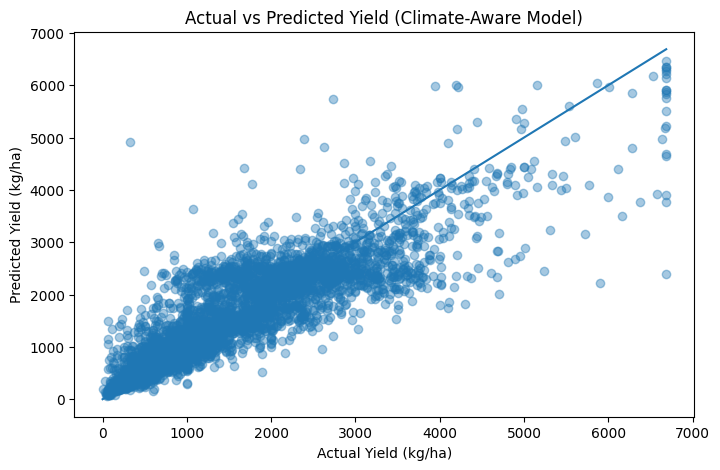

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title("Actual vs Predicted Yield (Climate-Aware Model)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()


In [9]:
# Extract feature names after preprocessing
ohe = yield_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["onehot"]

cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = numerical_features + list(cat_feature_names)

importances = yield_model.named_steps["model"].feature_importances_

import pandas as pd
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)


,Feature,Importance
9,Relative_Humidity,0.276487
19,Temp_Anomaly,0.184991
8,Rainfall_mm,0.127965
0,Year,0.061570
21,State_Andhra Pradesh,0.041908
34,State_Punjab,0.038669
36,State_Tamil Nadu,0.024437
1,Soil_Organic_Carbon,0.019928
4,Electrical_Conductivity,0.018847
17,Irrigation_Coverage,0.012718


In [10]:
import joblib

joblib.dump(yield_model, "CRA_Final_Yield_Prediction_Model.joblib")
print("Final yield model saved ✅")


Final yield model saved ✅
